# 2. Prétraitement des Données

**Projet Semesteriel - Détection de Fake News COVID-19**  
**Niveau 4CS | Superviseur : Prof. Salem Trabelsi**

---

## Objectif

Ce notebook couvre toutes les étapes de prétraitement des données :
- Nettoyage du texte (URLs, HTML, caractères spéciaux)
- Extraction de features linguistiques
- Tokenization pour BERT
- Analyse du déséquilibre des classes
- Découpage train/validation/test
- Sauvegarde des données prétraitées

## 2.1 Importation des bibliothèques

In [1]:
import os
import sys
import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Télécharger les ressources NLTK
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [3]:
# Ajouter le dossier src au path
sys.path.insert(0, os.path.join('..', 'src'))

# Essayer d'importer le module custom
try:
    from preprocessing.text_processor import TextProcessor
    print("Module TextProcessor importé depuis src/")
    USE_CUSTOM = True
except ImportError:
    print("Module TextProcessor non trouvé dans src/. Utilisation des fonctions locales.")
    USE_CUSTOM = False

print("Bibliothèques importées avec succès.")

Module TextProcessor non trouvé dans src/. Utilisation des fonctions locales.
Bibliothèques importées avec succès.


## 2.2 Chargement des données brutes

In [4]:
RAW_DATA_DIR = os.path.join('..', 'data', 'raw')
PROCESSED_DATA_DIR = os.path.join('..', 'data', 'processed')
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

# Charger les fichiers
possible_files = {
    'train': ['Constraint_Train.csv', 'train.csv', 'covid_fake_news_train.csv'],
    'val': ['Constraint_Val.csv', 'val.csv', 'covid_fake_news_val.csv'],
    'test': ['Constraint_Test.csv', 'test.csv', 'covid_fake_news_test.csv'],
    'full': ['covid_fake_news.csv', 'data.csv', 'dataset.csv', 'fake_news_covid.csv']
}

dataframes = {}
available_files = os.listdir(RAW_DATA_DIR) if os.path.exists(RAW_DATA_DIR) else []
print(f"Fichiers disponibles : {available_files}")

for split, filenames in possible_files.items():
    for fname in filenames:
        fpath = os.path.join(RAW_DATA_DIR, fname)
        if os.path.exists(fpath):
            dataframes[split] = pd.read_csv(fpath)
            print(f"[OK] {split}: {fname} ({dataframes[split].shape})")
            break

Fichiers disponibles : ['Constraint_Test.csv', 'Constraint_Train.csv', 'Constraint_Val.csv']
[OK] train: Constraint_Train.csv ((6420, 3))
[OK] val: Constraint_Val.csv ((2140, 3))
[OK] test: Constraint_Test.csv ((2140, 2))


In [5]:
if not dataframes:
    csv_files = [f for f in available_files if f.endswith('.csv')]
    if csv_files:
        dataframes['full'] = pd.read_csv(os.path.join(RAW_DATA_DIR, csv_files[0]))

# Verifier si le test a des labels
test_has_labels = False
if 'test' in dataframes:
    test_cols = [c.lower() for c in dataframes['test'].columns]
    test_has_labels = any(c in test_cols for c in ['label', 'class', 'target'])

In [6]:
# Combiner les donnees AVEC labels (train + val)
has_splits = all(s in dataframes for s in ['train', 'val'])

if 'full' in dataframes:
    df = dataframes['full'].copy()
elif has_splits:
    # Combiner uniquement train+val (test peut ne pas avoir de labels)
    labeled_splits = ['train', 'val']
    if test_has_labels:
        labeled_splits.append('test')
    df = pd.concat([dataframes[s] for s in labeled_splits if s in dataframes], ignore_index=True)
elif 'train' in dataframes:
    df = pd.concat([dataframes[s] for s in dataframes if s != 'test' or test_has_labels], ignore_index=True)
else:
    raise FileNotFoundError("Aucun fichier de donnees trouve.")

print(f"\nDataset charge (donnees labelisees) : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
print(f"Test a des labels : {test_has_labels}")


Dataset charge (donnees labelisees) : (8560, 3)
Colonnes : ['id', 'tweet', 'label']
Test a des labels : False


In [7]:
# Détecter colonnes de texte et label
text_col = None
label_col = None

for col in df.columns:
    col_lower = col.lower()
    if col_lower in ['tweet', 'text', 'content', 'news', 'article', 'sentence']:
        text_col = col
    if col_lower in ['label', 'class', 'target', 'category', 'fake']:
        label_col = col

if text_col is None:
    str_cols = df.select_dtypes(include='object').columns
    if len(str_cols) > 0:
        text_col = str_cols[df[str_cols].apply(lambda x: x.str.len().mean()).idxmax()]

if label_col is None:
    for col in df.columns:
        if df[col].nunique() <= 5 and col != text_col:
            label_col = col
            break

print(f"Colonne texte : '{text_col}'")
print(f"Colonne label : '{label_col}'")
print(f"Valeurs du label : {df[label_col].unique()}")

Colonne texte : 'tweet'
Colonne label : 'label'
Valeurs du label : ['real' 'fake']


## 2.3 Pipeline de nettoyage du texte

Le pipeline de nettoyage comprend les étapes suivantes :
1. Suppression des URLs
2. Suppression des balises HTML
3. Suppression des caractères spéciaux
4. Conversion en minuscules
5. Suppression des espaces multiples
6. Lemmatisation (optionnelle)

In [8]:
class TextCleaner:
    """Pipeline de nettoyage de texte pour la détection de fake news."""
    
    def __init__(self, remove_stopwords=False, lemmatize=False):
        self.remove_stopwords = remove_stopwords
        self.lemmatize = lemmatize
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()
    
    def remove_urls(self, text):
        """Supprimer les URLs."""
        url_pattern = re.compile(r'https?://\S+|www\.\S+')
        return url_pattern.sub('', text)
    
    def remove_html(self, text):
        """Supprimer les balises HTML."""
        html_pattern = re.compile(r'<[^>]+>')
        return html_pattern.sub('', text)
    
    def remove_special_chars(self, text):
        """Supprimer les caractères spéciaux, garder les lettres et chiffres."""
        text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    
    def remove_emojis(self, text):
        """Supprimer les emojis."""
        emoji_pattern = re.compile(
            "["
            u"\U0001F600-\U0001F64F"
            u"\U0001F300-\U0001F5FF"
            u"\U0001F680-\U0001F6FF"
            u"\U0001F1E0-\U0001F1FF"
            u"\U00002702-\U000027B0"
            u"\U000024C2-\U0001F251"
            "]+", flags=re.UNICODE
        )
        return emoji_pattern.sub('', text)
    
    def clean(self, text):
        """Appliquer le pipeline complet de nettoyage."""
        if not isinstance(text, str):
            return ''
        
        text = self.remove_urls(text)
        text = self.remove_html(text)
        text = self.remove_emojis(text)
        text = text.lower()
        text = self.remove_special_chars(text)
        
        if self.remove_stopwords or self.lemmatize:
            tokens = word_tokenize(text)
            if self.remove_stopwords:
                tokens = [t for t in tokens if t not in self.stop_words]
            if self.lemmatize:
                tokens = [self.lemmatizer.lemmatize(t) for t in tokens]
            text = ' '.join(tokens)
        
        return text

In [9]:
# Utiliser le module custom s'il existe, sinon utiliser la classe locale
if USE_CUSTOM:
    cleaner = TextProcessor()
    print("Utilisation du TextProcessor custom depuis src/")
else:
    cleaner = TextCleaner(remove_stopwords=False, lemmatize=False)
    print("Utilisation du TextCleaner local")

Utilisation du TextCleaner local


In [10]:
# Exemples de nettoyage avant/après
print("=" * 60)
print("EXEMPLES DE NETTOYAGE")
print("=" * 60)

examples = df[text_col].dropna().sample(5, random_state=42)
for i, text in enumerate(examples, 1):
    original = str(text)[:200]
    cleaned = cleaner.clean(str(text))[:200]
    print(f"\n--- Exemple {i} ---")
    print(f"AVANT : {original}")
    print(f"APRÈS : {cleaned}")

EXEMPLES DE NETTOYAGE

--- Exemple 1 ---
AVANT : *Recovered* ➡️Those who have had the disease. We assume that these people acquire long-lasting immunity though people only remain immune to other coronaviruses for 1-2 years (avg) and there is some ea
APRÈS : recovered those who have had the disease we assume that these people acquire long lasting immunity though people only remain immune to other coronaviruses for 1 2 years avg and there is some early evi

--- Exemple 2 ---
AVANT : Coronavirus is leading to a global oxygen shortage. https://t.co/squGcdAvMB https://t.co/E7vVP5mwrY
APRÈS : coronavirus is leading to a global oxygen shortage

--- Exemple 3 ---
AVANT : As of the 6th of July more than 70000 #COVID19 cases have been reported among indigenous peoples in the Americas and more than two thousand deaths. Most recently at least six cases have been reported 
APRÈS : as of the 6th of july more than 70000 covid19 cases have been reported among indigenous peoples in the americas and mor

In [11]:
# Appliquer le nettoyage à tout le dataset
print("Nettoyage du texte en cours...")
df['cleaned_text'] = df[text_col].astype(str).apply(cleaner.clean)

# Vérifier les textes vides après nettoyage
empty_after_clean = (df['cleaned_text'].str.strip() == '').sum()
print(f"\nTextes vides après nettoyage : {empty_after_clean}")

# Supprimer les textes vides
if empty_after_clean > 0:
    df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)
    print(f"Taille du dataset après suppression des vides : {len(df)}")

print(f"\nNettoyage terminé. Dataset : {df.shape}")

Nettoyage du texte en cours...

Textes vides après nettoyage : 0

Nettoyage terminé. Dataset : (8560, 4)


## 2.4 Extraction de features linguistiques

Nous extrayons des features numériques à partir du texte pour enrichir nos modèles.

In [12]:
def extract_linguistic_features(df, text_col, original_text_col):
    """Extraire des features linguistiques du texte."""
    features = pd.DataFrame()
    
    # Features basées sur le texte nettoyé
    features['word_count'] = df[text_col].apply(lambda x: len(str(x).split()))
    features['char_count'] = df[text_col].apply(lambda x: len(str(x)))
    features['avg_word_length'] = df[text_col].apply(
        lambda x: np.mean([len(w) for w in str(x).split()]) if len(str(x).split()) > 0 else 0
    )
    features['unique_word_count'] = df[text_col].apply(
        lambda x: len(set(str(x).split()))
    )
    features['unique_word_ratio'] = features['unique_word_count'] / (features['word_count'] + 1)
    
    # Features basées sur le texte original
    features['exclamation_count'] = df[original_text_col].astype(str).apply(
        lambda x: x.count('!')
    )
    features['question_count'] = df[original_text_col].astype(str).apply(
        lambda x: x.count('?')
    )
    features['uppercase_ratio'] = df[original_text_col].astype(str).apply(
        lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1)
    )
    features['punctuation_count'] = df[original_text_col].astype(str).apply(
        lambda x: sum(1 for c in x if c in string.punctuation)
    )
    features['hashtag_count'] = df[original_text_col].astype(str).apply(
        lambda x: x.count('#')
    )
    features['mention_count'] = df[original_text_col].astype(str).apply(
        lambda x: x.count('@')
    )
    features['url_count'] = df[original_text_col].astype(str).apply(
        lambda x: len(re.findall(r'https?://\S+', x))
    )
    
    return features

In [13]:
print("Extraction des features linguistiques...")
features_df = extract_linguistic_features(df, 'cleaned_text', text_col)

# Ajouter les features au dataframe
for col in features_df.columns:
    df[col] = features_df[col]

print(f"Features extraites : {list(features_df.columns)}")
print(f"\nStatistiques des features :")
features_df.describe().round(2)

Extraction des features linguistiques...


Features extraites : ['word_count', 'char_count', 'avg_word_length', 'unique_word_count', 'unique_word_ratio', 'exclamation_count', 'question_count', 'uppercase_ratio', 'punctuation_count', 'hashtag_count', 'mention_count', 'url_count']

Statistiques des features :


,word_count,char_count,avg_word_length,unique_word_count,unique_word_ratio,exclamation_count,question_count,uppercase_ratio,punctuation_count,hashtag_count,mention_count,url_count
count,8560.00,8560.00,8560.00,8560.00,8560.00,8560.00,8560.00,8560.00,8560.00,8560.00,8560.00,8560.00
mean,27.38,159.80,5.00,24.05,0.87,0.06,0.21,0.08,8.66,0.79,0.33,0.69
std,23.22,132.18,0.83,13.75,0.07,0.33,1.19,0.05,6.86,1.60,1.25,0.76
min,2.00,9.00,2.89,2.00,0.44,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,15.00,93.00,4.46,15.00,0.83,0.00,0.00,0.04,3.00,0.00,0.00,0.00
50%,25.00,148.00,4.89,23.00,0.88,0.00,0.00,0.07,7.00,0.00,0.00,1.00
75%,38.00,225.00,5.41,32.00,0.92,0.00,0.00,0.10,12.00,1.00,0.00,1.00
max,1505.00,8701.00,12.91,657.00,0.98,7.00,34.00,0.85,152.00,15.00,50.00,14.00


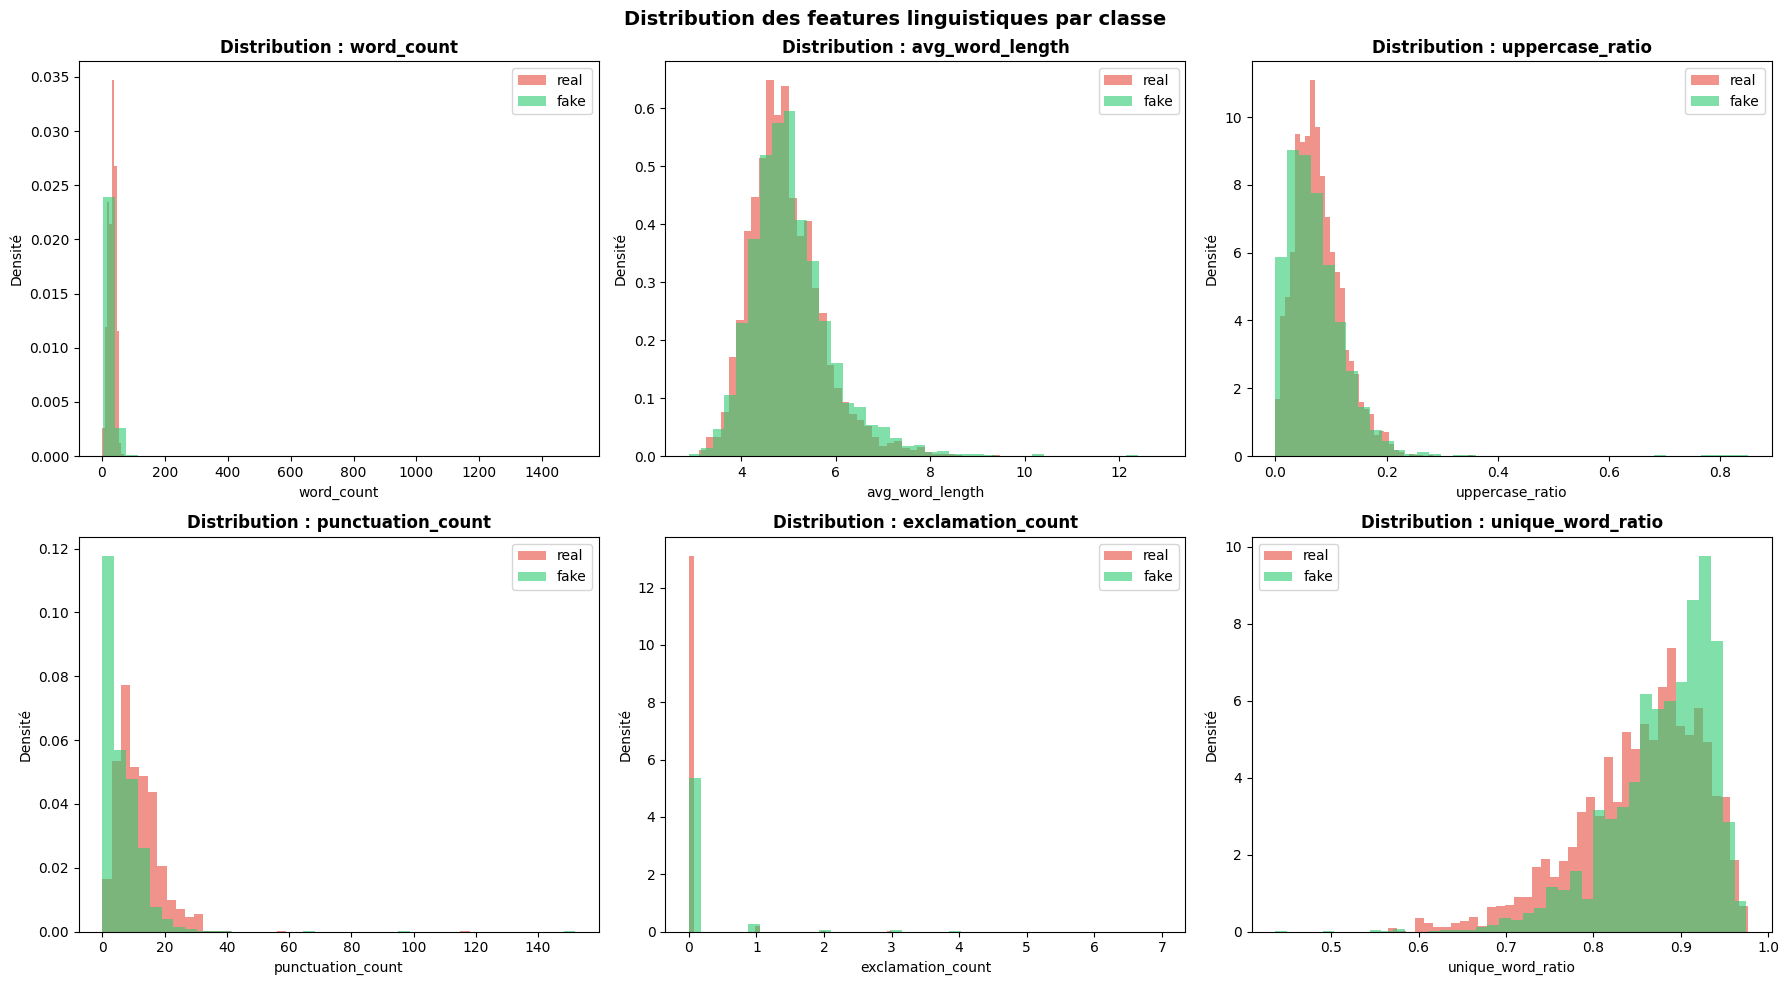

In [14]:
# Visualisation des distributions de features par classe
feature_cols = ['word_count', 'avg_word_length', 'uppercase_ratio',
                'punctuation_count', 'exclamation_count', 'unique_word_ratio']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors = ['#e74c3c', '#2ecc71']

for idx, feat in enumerate(feature_cols):
    ax = axes[idx // 3, idx % 3]
    for cls, color in zip(df[label_col].unique(), colors):
        subset = df[df[label_col] == cls]
        ax.hist(subset[feat], bins=40, alpha=0.6, label=cls, color=color, density=True)
    ax.set_title(f'Distribution : {feat}', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Densité')
    ax.legend()

plt.suptitle('Distribution des features linguistiques par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.5 Tokenisation pour BERT

BERT utilise un tokenizer spécifique (WordPiece). Nous montrons ici comment le texte est tokenisé pour être utilisé avec le modèle BERT.

In [15]:
try:
    from transformers import BertTokenizer
    
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    print("Tokenizer BERT charge avec succes.")
    print(f"Taille du vocabulaire : {tokenizer.vocab_size}")
    
    # Exemples de tokenisation
    print("\n" + "=" * 60)
    print("EXEMPLES DE TOKENISATION BERT")
    print("=" * 60)
    
    samples = df['cleaned_text'].sample(3, random_state=42)
    for i, text in enumerate(samples, 1):
        text_short = str(text)[:200]
        encoded = tokenizer(
            text_short,
            max_length=128,
            truncation=True,
            padding='max_length',
            return_attention_mask=True,
            return_tensors=None
        )
        tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][:30])
        
        print(f"\n--- Exemple {i} ---")
        print(f"Texte : {text_short[:100]}...")
        print(f"Tokens (30 premiers) : {tokens}")
        print(f"Input IDs (30 premiers) : {encoded['input_ids'][:30]}")
        print(f"Attention Mask (30 premiers) : {encoded['attention_mask'][:30]}")
        print(f"Nombre total de tokens : {sum(encoded['attention_mask'])}")
    
    BERT_AVAILABLE = True

except ImportError:
    print("La bibliotheque transformers n'est pas installee.")
    BERT_AVAILABLE = False

Tokenizer BERT charge avec succes.
Taille du vocabulaire : 30522

EXEMPLES DE TOKENISATION BERT

--- Exemple 1 ---
Texte : recovered those who have had the disease we assume that these people acquire long lasting immunity t...
Tokens (30 premiers) : ['[CLS]', 'recovered', 'those', 'who', 'have', 'had', 'the', 'disease', 'we', 'assume', 'that', 'these', 'people', 'acquire', 'long', 'lasting', 'immunity', 'though', 'people', 'only', 'remain', 'immune', 'to', 'other', 'corona', '##virus', '##es', 'for', '1', '2']
Input IDs (30 premiers) : [101, 6757, 2216, 2040, 2031, 2018, 1996, 4295, 2057, 7868, 2008, 2122, 2111, 9878, 2146, 9879, 15403, 2295, 2111, 2069, 3961, 11311, 2000, 2060, 21887, 23350, 2229, 2005, 1015, 1016]
Attention Mask (30 premiers) : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Nombre total de tokens : 41

--- Exemple 2 ---
Texte : coronavirus is leading to a global oxygen shortage...
Tokens (30 premiers) : ['[CLS]', 'corona', 

Calcul de la distribution des longueurs de tokens...


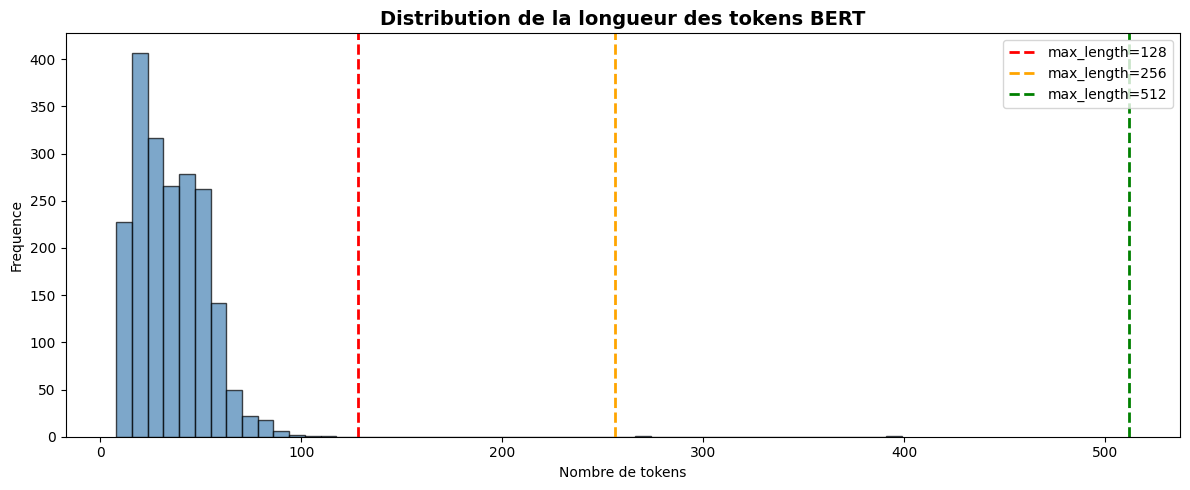

max_length=64 : 89 textes tronques (4.5%)
max_length=128 : 2 textes tronques (0.1%)
max_length=256 : 2 textes tronques (0.1%)
max_length=512 : 0 textes tronques (0.0%)


In [16]:
# Distribution de la longueur des tokens BERT
if BERT_AVAILABLE:
    print("Calcul de la distribution des longueurs de tokens...")
    token_lengths = df['cleaned_text'].sample(min(2000, len(df)), random_state=42).apply(
        lambda x: len(tokenizer.tokenize(str(x))) + 2  # +2 for [CLS] and [SEP]
    )
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(token_lengths, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(x=128, color='red', linestyle='--', linewidth=2, label='max_length=128')
    ax.axvline(x=256, color='orange', linestyle='--', linewidth=2, label='max_length=256')
    ax.axvline(x=512, color='green', linestyle='--', linewidth=2, label='max_length=512')
    ax.set_title('Distribution de la longueur des tokens BERT', fontsize=14, fontweight='bold')
    ax.set_xlabel('Nombre de tokens')
    ax.set_ylabel('Frequence')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../reports/figures/bert_token_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    for max_len in [64, 128, 256, 512]:
        truncated = (token_lengths > max_len).sum()
        pct = truncated / len(token_lengths) * 100
        print(f"max_length={max_len} : {truncated} textes tronques ({pct:.1f}%)")

## 2.6 Analyse du déséquilibre des classes

In [17]:
print("=" * 60)
print("ANALYSE DU DÉSÉQUILIBRE DES CLASSES")
print("=" * 60)

class_counts = df[label_col].value_counts()
print(f"\nDistribution :")
for cls, count in class_counts.items():
    print(f"  {cls}: {count} ({count/len(df)*100:.1f}%)")

ratio = class_counts.max() / class_counts.min()
print(f"\nRatio de déséquilibre : {ratio:.2f}:1")

if ratio > 1.5:
    print("\nLe dataset présente un déséquilibre notable.")
    print("Stratégies possibles :")
    print("  1. Sur-échantillonnage de la classe minoritaire (SMOTE)")
    print("  2. Sous-échantillonnage de la classe majoritaire")
    print("  3. Poids de classe dans la fonction de perte")
    print("  4. Métriques adaptées (F1-score, AUC-ROC)")
else:
    print("\nLe dataset est relativement équilibré.")
    print("Pas de technique de rééquilibrage nécessaire.")

ANALYSE DU DÉSÉQUILIBRE DES CLASSES

Distribution :
  real: 4480 (52.3%)
  fake: 4080 (47.7%)

Ratio de déséquilibre : 1.10:1

Le dataset est relativement équilibré.
Pas de technique de rééquilibrage nécessaire.


In [18]:
# Calculer les poids de classe pour la loss function
total = len(df)
n_classes = df[label_col].nunique()
class_weights = {}
for cls, count in class_counts.items():
    class_weights[cls] = total / (n_classes * count)
print(f"\nPoids de classe suggérés : {class_weights}")


Poids de classe suggérés : {'real': 0.9553571428571429, 'fake': 1.0490196078431373}


## 2.7 Encodage des labels et découpage train/val/test

In [19]:
# Encoder les labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df[label_col])

print("Mapping des labels :")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} -> {i}")

Mapping des labels :
  fake -> 0
  real -> 1


In [20]:
# Decoupage train/val/test
if has_splits:
    print("\nLe dataset contient des splits predefinis.")
    train_size = len(dataframes.get('train', pd.DataFrame()))
    val_size = len(dataframes.get('val', pd.DataFrame()))

    df_train = df.iloc[:train_size]
    df_val = df.iloc[train_size:train_size + val_size]

    if test_has_labels and 'test' in dataframes:
        df_test = df.iloc[train_size + val_size:]
    else:
        # Pas de labels test - utiliser val comme test pour l'evaluation
        df_test = df_val.copy()
        print("  Note: test sans labels -> val utilise comme jeu de test")
else:
    print("\nCreation des splits train/val/test (70/15/15)...")
    df_train, df_temp = train_test_split(
        df, test_size=0.3, random_state=42, stratify=df['label_encoded']
    )
    df_val, df_test = train_test_split(
        df_temp, test_size=0.5, random_state=42, stratify=df_temp['label_encoded']
    )


Le dataset contient des splits predefinis.
  Note: test sans labels -> val utilise comme jeu de test


In [21]:
print(f"\nTailles des splits :")
print(f"  Train : {len(df_train)} ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Val   : {len(df_val)} ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Test  : {len(df_test)} ({len(df_test)/len(df)*100:.1f}%)")

# Verifier la stratification
print(f"\nDistribution des classes par split :")
for name, split_df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    dist = split_df[label_col].value_counts(normalize=True) * 100
    print(f"  {name}: {dict(dist.round(1))}")


Tailles des splits :
  Train : 6420 (75.0%)
  Val   : 2140 (25.0%)
  Test  : 2140 (25.0%)

Distribution des classes par split :
  Train: {'real': np.float64(52.3), 'fake': np.float64(47.7)}
  Val: {'real': np.float64(52.3), 'fake': np.float64(47.7)}
  Test: {'real': np.float64(52.3), 'fake': np.float64(47.7)}


## 2.8 Visualisation avant/après prétraitement

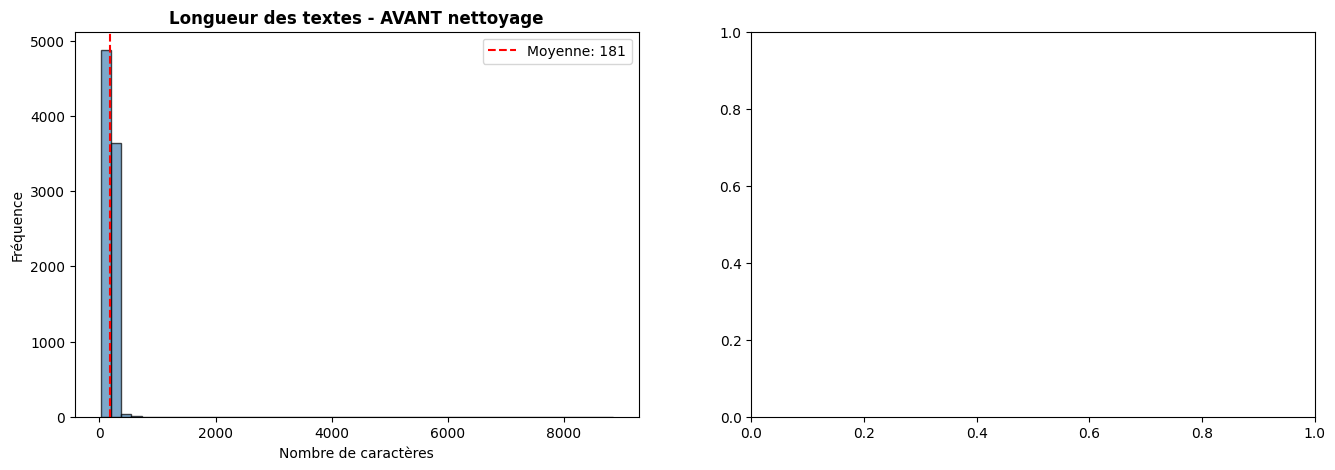

In [22]:
# Comparer les longueurs avant/après nettoyage
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Avant nettoyage
original_lengths = df[text_col].astype(str).apply(len)
axes[0].hist(original_lengths, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Longueur des textes - AVANT nettoyage', fontweight='bold')
axes[0].set_xlabel('Nombre de caractères')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(x=original_lengths.mean(), color='red', linestyle='--', label=f'Moyenne: {original_lengths.mean():.0f}')
axes[0].legend()

In [23]:
# Après nettoyage
cleaned_lengths = df['cleaned_text'].apply(len)
axes[1].hist(cleaned_lengths, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_title('Longueur des textes - APRÈS nettoyage', fontweight='bold')
axes[1].set_xlabel('Nombre de caractères')
axes[1].set_ylabel('Fréquence')
axes[1].axvline(x=cleaned_lengths.mean(), color='red', linestyle='--', label=f'Moyenne: {cleaned_lengths.mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/before_after_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [24]:
# Réduction moyenne
reduction = (1 - cleaned_lengths.mean() / original_lengths.mean()) * 100
print(f"Réduction moyenne de la longueur : {reduction:.1f}%")

Réduction moyenne de la longueur : 11.8%


## 2.9 Sauvegarde des données prétraitées

In [25]:
# Sauvegarder les CSV prétraités
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

# Colonnes à sauvegarder
save_cols = [text_col, 'cleaned_text', label_col, 'label_encoded'] + list(features_df.columns)
save_cols = [c for c in save_cols if c in df.columns]

df_train[save_cols].to_csv(os.path.join(PROCESSED_DATA_DIR, 'train_processed.csv'), index=False)
df_val[save_cols].to_csv(os.path.join(PROCESSED_DATA_DIR, 'val_processed.csv'), index=False)
df_test[save_cols].to_csv(os.path.join(PROCESSED_DATA_DIR, 'test_processed.csv'), index=False)

print("Fichiers CSV sauvegardés :")
print(f"  {PROCESSED_DATA_DIR}/train_processed.csv ({len(df_train)} lignes)")
print(f"  {PROCESSED_DATA_DIR}/val_processed.csv ({len(df_val)} lignes)")
print(f"  {PROCESSED_DATA_DIR}/test_processed.csv ({len(df_test)} lignes)")

Fichiers CSV sauvegardés :
  ..\data\processed/train_processed.csv (6420 lignes)
  ..\data\processed/val_processed.csv (2140 lignes)
  ..\data\processed/test_processed.csv (2140 lignes)


In [26]:
# Sauvegarder les tensors PyTorch pour BERT
try:
    import torch
    
    if BERT_AVAILABLE:
        MAX_LENGTH = 128
        
        def tokenize_and_encode(texts, labels, max_length=MAX_LENGTH):
            """Tokeniser et encoder les textes pour BERT."""
            encodings = tokenizer(
                texts.tolist(),
                max_length=max_length,
                truncation=True,
                padding='max_length',
                return_tensors='pt'
            )
            labels_tensor = torch.tensor(labels.values, dtype=torch.long)
            return {
                'input_ids': encodings['input_ids'],
                'attention_mask': encodings['attention_mask'],
                'labels': labels_tensor
            }
        
        print("Tokenisation et encodage pour BERT...")
        
        train_encoded = tokenize_and_encode(df_train['cleaned_text'], df_train['label_encoded'])
        val_encoded = tokenize_and_encode(df_val['cleaned_text'], df_val['label_encoded'])
        test_encoded = tokenize_and_encode(df_test['cleaned_text'], df_test['label_encoded'])
        
        # Sauvegarder les tenseurs
        torch.save(train_encoded, os.path.join(PROCESSED_DATA_DIR, 'train_bert.pt'))
        torch.save(val_encoded, os.path.join(PROCESSED_DATA_DIR, 'val_bert.pt'))
        torch.save(test_encoded, os.path.join(PROCESSED_DATA_DIR, 'test_bert.pt'))
        
        print("\nTenseurs PyTorch sauvegardes :")
        print(f"  train_bert.pt : input_ids shape = {train_encoded['input_ids'].shape}")
        print(f"  val_bert.pt   : input_ids shape = {val_encoded['input_ids'].shape}")
        print(f"  test_bert.pt  : input_ids shape = {test_encoded['input_ids'].shape}")
    else:
        print("BERT tokenizer non disponible. Les tenseurs ne seront pas crees.")

except ImportError:
    print("PyTorch n'est pas installe. Les tenseurs ne seront pas crees.")

Tokenisation et encodage pour BERT...



Tenseurs PyTorch sauvegardes :
  train_bert.pt : input_ids shape = torch.Size([6420, 128])
  val_bert.pt   : input_ids shape = torch.Size([2140, 128])
  test_bert.pt  : input_ids shape = torch.Size([2140, 128])


In [27]:
# Sauvegarder le mapping des labels et les métadonnées
import json

metadata = {
    'text_column': text_col,
    'label_column': label_col,
    'label_mapping': {str(cls): int(idx) for idx, cls in enumerate(le.classes_)},
    'train_size': len(df_train),
    'val_size': len(df_val),
    'test_size': len(df_test),
    'total_size': len(df),
    'feature_columns': list(features_df.columns),
    'class_weights': {str(k): float(v) for k, v in class_weights.items()}
}

with open(os.path.join(PROCESSED_DATA_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print("Métadonnées sauvegardées dans metadata.json")
print(f"\nPrétraitement terminé avec succès !")

Métadonnées sauvegardées dans metadata.json

Prétraitement terminé avec succès !
